In [2]:
DICOM_DIR="/Users/nomura/work/Dr_horaguchi/DICOM normal/1/"
NIFTI_DIR="/Users/nomura/work/Dr_horaguchi/nifti/normal/1"
!mkdir -p "$NIFTI_DIR"

!dcm2niix -z y -o "$NIFTI_DIR" "$DICOM_DIR"
!ls -lh "$NIFTI_DIR"

Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 10 DICOM file(s)
Convert 10 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/normal/1/1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2k (512x512x10x1)
Conversion required 0.235099 seconds (0.222197 for core code).
total 56736
-rw-r--r--  1 nomura  staff   947B  2月 10 04:58 1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2.json
-rw-r--r--  1 nomura  staff   2.3M  2月 10 04:58 1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2.nii.gz
-rw-r--r--  1 nomura  staff   947B  2月 10 05:31 1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2a.json
-rw-r--r--  1 nomura  staff   2.3M  2月 10 05:31 1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2a.nii.gz
-rw-r--r--  1 nomura  staff   947B  2月 10 05:34 1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2b.json
-rw-r--r--  1 nomura  staff   2

In [3]:
!chmod u+x /Users/nomura/miniconda3/envs/totalseg/lib/python3.10/site-packages/torch/bin/torch_shm_manager

In [4]:
CT_NIFTI="/Users/nomura/work/Dr_horaguchi/nifti/normal/1/1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2.nii.gz"
OUT_DIR="/Users/nomura/work/Dr_horaguchi/seg_out/normal/1/"
!mkdir -p "$OUT_DIR"

!TotalSegmentator -i "$CT_NIFTI" -o "$OUT_DIR"  --fast --roi_subset gallbladder
!ls -lh "$OUT_DIR"

No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.19s
Predicting...
100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  1.61it/s]
  Predicted in 5.78s
Resampling...
INFO: Crop is empty. Returning empty segmentation.
total 4704
-rw-r--r--  1 nomura  staff    11K  4月 23 10:26 gallbladder.nii.gz
-rw-r--r--  1 nomura  staff    21K  4月 17 08:44 liver.nii.gz
-rw-r--r--  1 nomura  staff   283K  2月 10 09:09 overlay_top001_z009.png
-rw-r--r--  1 nomura  staff   281K  2月 10 09:09 overlay_top002_z008.png
-rw-r--r--  1 nomura  staff   278K  2月 10 09:09 overlay_top003_z007.png
-rw-r--r--  1 nomura  staff   276K  2月 10 09:09 overlay_top004_z006.png
-rw-r--r--  1 nomura  staff   277K  2月 10 09:

In [5]:
import nibabel as nib, numpy as np
img = nib.load("/Users/nomura/work/Dr_horaguchi/nifti/normal/1/1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2.nii.gz")
x = img.get_fdata()
print("shape:", x.shape)
print("min/mean/median/max:", np.min(x), np.mean(x), np.median(x), np.max(x))


shape: (512, 512, 10)
min/mean/median/max: -3024.0 -1059.787062072754 -922.0 1118.0


In [12]:
!TotalSegmentator -i "$CT_NIFTI" -o "$OUT_DIR"  \
  --roi_subset liver pancreas spleen stomach gallbladder


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.19s
Predicting...
100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  1.84it/s]
  Predicted in 5.70s
Resampling...
  cropping from (512, 512, 10) to (283, 217, 10)
Resampling...
  Resampled in 0.10s
Predicting part 1 of 1 ...
100%|█████████████████████████████████████████████| 2/2 [00:16<00:00,  8.47s/it]
  Predicted in 22.54s
Resampling...
Saving segmentations...
  Saved in 3.64s


In [13]:
seg = nib.load("/Users/nomura/work/Dr_horaguchi/seg_out/normal/1/gallbladder.nii.gz").get_fdata()
print("nonzero voxels:", np.count_nonzero(seg))

nonzero voxels: 5488


nonzero voxels: 78455


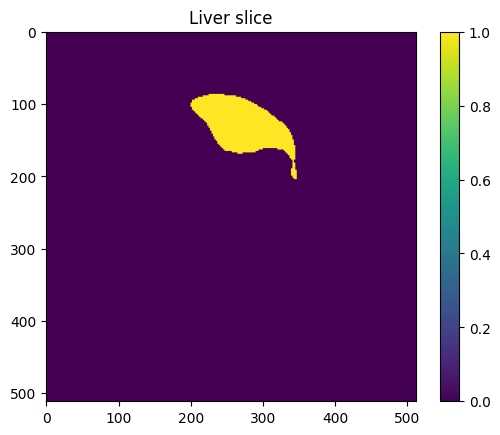

In [17]:
seg = nib.load("/Users/nomura/work/Dr_horaguchi/seg_out/normal/1/liver.nii.gz").get_fdata()
print("nonzero voxels:", np.count_nonzero(seg))
import matplotlib.pyplot as plt
plt.imshow(seg[:, :, seg.shape[2]//2])
plt.title("Liver slice")
plt.colorbar()
plt.show()

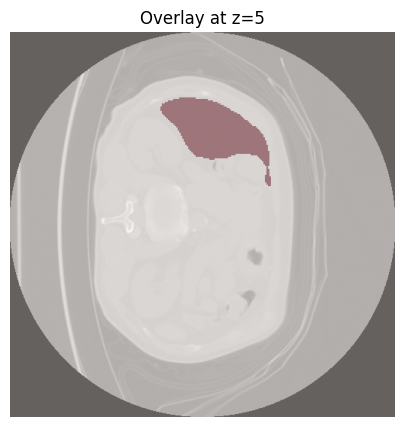

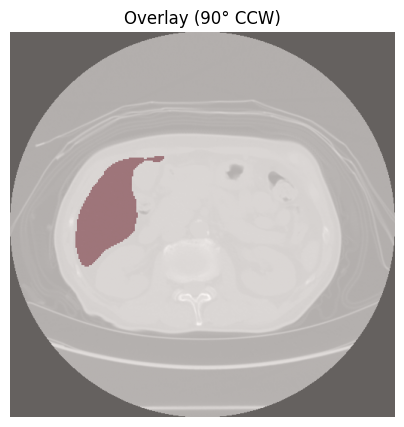

In [18]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

img = nib.load("/Users/nomura/work/Dr_horaguchi/nifti/normal/1/1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2.nii.gz").get_fdata()
seg = nib.load("/Users/nomura/work/Dr_horaguchi/seg_out/normal/1/liver.nii.gz").get_fdata()

z = seg.shape[2]//2

plt.figure(figsize=(5,5))
plt.imshow(img[:, :, z], cmap="gray")
plt.imshow(seg[:, :, z], alpha=0.4, cmap="Reds")
plt.title(f"Overlay at z={z}")
plt.axis("off")
plt.show()

rot_img = np.rot90(img[:, :, z], k=1)
rot_seg = np.rot90(seg[:, :, z], k=1)

plt.figure(figsize=(5,5))
plt.imshow(rot_img, cmap="gray")
plt.imshow(rot_seg, alpha=0.4, cmap="Reds")
plt.title("Overlay (90° CCW)")
plt.axis("off")
plt.show()

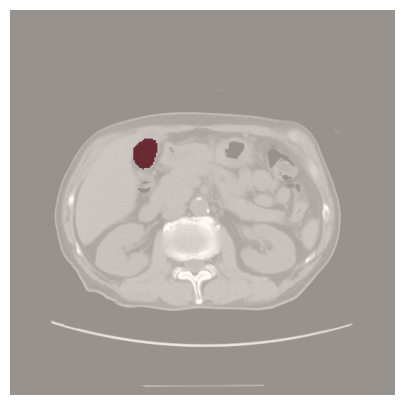

In [19]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

img = nib.load("/Users/nomura/work/Dr_horaguchi/nifti/normal/1/1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2.nii.gz").get_fdata()
seg = nib.load("/Users/nomura/work/Dr_horaguchi/seg_out/normal/1/gallbladder.nii.gz").get_fdata()

z = seg.shape[2]//2


rot_img = np.rot90(img[:, :, z], k=1)
rot_seg = np.rot90(seg[:, :, z], k=1)

plt.figure(figsize=(5,5))
plt.imshow(rot_img, cmap="gray", vmin=-200, vmax=300)
plt.imshow(rot_seg, alpha=0.6, cmap="Reds")
plt.axis("off")
plt.gca().set_facecolor("black")
plt.show()

